# TESTS

Test file for experimenting with sklearn and pytorch before deciding on the architecture

## 1. Scikit-Learn

### Model choice

In [ ]:
"""
Scikit-Learn Model for COPD Prediction
"""

import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

from data_prep import prepare_data, DISEASE_SHORT_NAMES


# =============================================================================
# 1. LOAD DATA
# =============================================================================
TARGET = 'Maladie pulmonaire obstructive chronique'  # COPD

data = prepare_data(target_disease=TARGET)

print(f"Target: {DISEASE_SHORT_NAMES[TARGET]}")
print(f"Training samples: {data.n_train_samples}")
print(f"Test samples: {data.n_test_samples}")
print(f"Features: {data.feature_names}")


# =============================================================================
# 2. TRAIN MODELS
# =============================================================================
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
}

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

results = {}
for name, model in models.items():
    # Train
    model.fit(data.X_train, data.y_train)
    
    # Predict
    y_pred = model.predict(data.X_test)
    
    # Evaluate
    r2 = r2_score(data.y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(data.y_test, y_pred))
    
    results[name] = {'model': model, 'r2': r2, 'rmse': rmse}
    print(f"{name:20s} | R² = {r2:.4f} | RMSE = {rmse:.1f}")

# Best model
best_name = max(results, key=lambda k: results[k]['r2'])
print(f"\n→ Best: {best_name} (R² = {results[best_name]['r2']:.4f})")


Target: COPD
Training samples: 5897
Test samples: 1475
Features: ['bc', 'co', 'nh3', 'nmvoc', 'nox', 'oc', 'pm10', 'pm25', 'so2', 'year']

MODEL COMPARISON
Ridge                | R² = 0.1564 | RMSE = 9188.9
Random Forest        | R² = 0.7373 | RMSE = 5128.3
Gradient Boosting    | R² = 0.7715 | RMSE = 4782.2

→ Best: Gradient Boosting (R² = 0.7715)


### Lag Analysis

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

from data_prep import prepare_data, DISEASES, DISEASE_SHORT_NAMES

# =============================================================================
# LAG ANALYSIS: Find optimal lag for each disease
# =============================================================================
print("LAG ANALYSIS BY DISEASE")
print("="*60)

for rs in [1, 10, 30, 84]:
    print(f"\nRandom State: {rs}")
    for disease in DISEASES:
        short_name = DISEASE_SHORT_NAMES[disease]
        print(f"\n{short_name}:")
        
        for lag in [0, 3, 6, 9]:
            data = prepare_data(target_disease=disease, lag_years=lag, random_state=None)
            
            model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=rs)
            model.fit(data.X_train, data.y_train)
            
            r2 = r2_score(data.y_test, model.predict(data.X_test))
            print(f"  Lag {lag} years | R² = {r2:.4f}")


LAG ANALYSIS BY DISEASE

Random State: 1

Lung Cancer:
  Lag 0 years | R² = 0.8567
  Lag 3 years | R² = 0.8625
  Lag 6 years | R² = 0.8720
  Lag 9 years | R² = 0.8660

Pneumoconiosis:
  Lag 0 years | R² = 0.8058
  Lag 3 years | R² = 0.7868
  Lag 6 years | R² = 0.7367
  Lag 9 years | R² = 0.7928

COPD:
  Lag 0 years | R² = 0.7937
  Lag 3 years | R² = 0.7811
  Lag 6 years | R² = 0.7924
  Lag 9 years | R² = 0.8119

Asthma:
  Lag 0 years | R² = 0.8470
  Lag 3 years | R² = 0.8389
  Lag 6 years | R² = 0.7870
  Lag 9 years | R² = 0.8326

Other Chronic Resp.:
  Lag 0 years | R² = 0.6968
  Lag 3 years | R² = 0.6897
  Lag 6 years | R² = 0.7314
  Lag 9 years | R² = 0.7244

Random State: 10

Lung Cancer:
  Lag 0 years | R² = 0.8617
  Lag 3 years | R² = 0.8615
  Lag 6 years | R² = 0.8646
  Lag 9 years | R² = 0.8814

Pneumoconiosis:
  Lag 0 years | R² = 0.7652
  Lag 3 years | R² = 0.5429
  Lag 6 years | R² = 0.6877
  Lag 9 years | R² = 0.8087

COPD:
  Lag 0 years | R² = 0.7578
  Lag 3 years | R² = 0

The lag depends on the disease, but it depends a lot on the random state of the model. Pneumoconiosis and other diseases have better results with 6-9 years, but pneumocnoniosis also has a high r2 at 0. Asthma is usally stable, same for COPD and lung cancer. The lag is pretty unstable, so we'll scrap that idea.

## PyTorch

### Output from `pt_model.py`


```
(nf21_respiratory_diseases)  : nf21_respiratory_diseases (main) malcolm % python -u "/Users/malcolm/Documents/Cours/UTT/
ISI1/NF21/nf21_respiratory_diseases/model/pt_model.py"
PYTORCH MLP - ALL DISEASES
==================================================
Lung Cancer               | R² = 0.6264
Pneumoconiosis            | R² = 0.6034
COPD                      | R² = 0.3774
Asthma                    | R² = 0.5332
Other Chronic Resp.       | R² = 0.4709
```

## Hyperparameter Tuning (COPD only)

In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

from data_prep import prepare_data

TARGET = 'Maladie pulmonaire obstructive chronique'
data = prepare_data(target_disease=TARGET, lag_years=0)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=10),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

print("Running GridSearchCV... (this may take a minute)")
grid.fit(data.X_train, data.y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV R²: {grid.best_score_:.4f}")

# Test set evaluation
best_model = grid.best_estimator_
test_r2 = r2_score(data.y_test, best_model.predict(data.X_test))
print(f"Test R²: {test_r2:.4f}")

Running GridSearchCV... (this may take a minute)

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best CV R²: 0.9015
Test R²: 0.9249


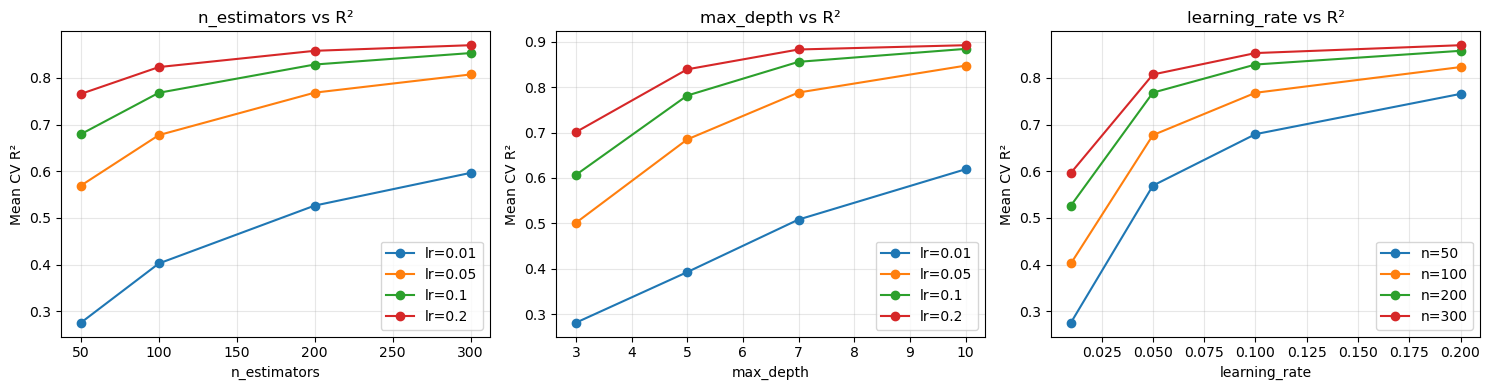


→ Best configuration: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}


In [3]:
# Plot: R² vs n_estimators for different learning rates
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. n_estimators vs R² (grouped by learning_rate)
ax = axes[0]
for lr in param_grid['learning_rate']:
    mask = results['param_learning_rate'] == lr
    subset = results[mask].groupby('param_n_estimators')['mean_test_score'].mean()
    ax.plot(subset.index, subset.values, marker='o', label=f'lr={lr}')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Mean CV R²')
ax.set_title('n_estimators vs R²')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. max_depth vs R² (grouped by learning_rate)
ax = axes[1]
for lr in param_grid['learning_rate']:
    mask = results['param_learning_rate'] == lr
    subset = results[mask].groupby('param_max_depth')['mean_test_score'].mean()
    ax.plot(subset.index, subset.values, marker='o', label=f'lr={lr}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Mean CV R²')
ax.set_title('max_depth vs R²')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. learning_rate vs R² (grouped by n_estimators)
ax = axes[2]
for n in param_grid['n_estimators']:
    mask = results['param_n_estimators'] == n
    subset = results[mask].groupby('param_learning_rate')['mean_test_score'].mean()
    ax.plot(subset.index, subset.values, marker='o', label=f'n={n}')
ax.set_xlabel('learning_rate')
ax.set_ylabel('Mean CV R²')
ax.set_title('learning_rate vs R²')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n→ Best configuration: {grid.best_params_}")

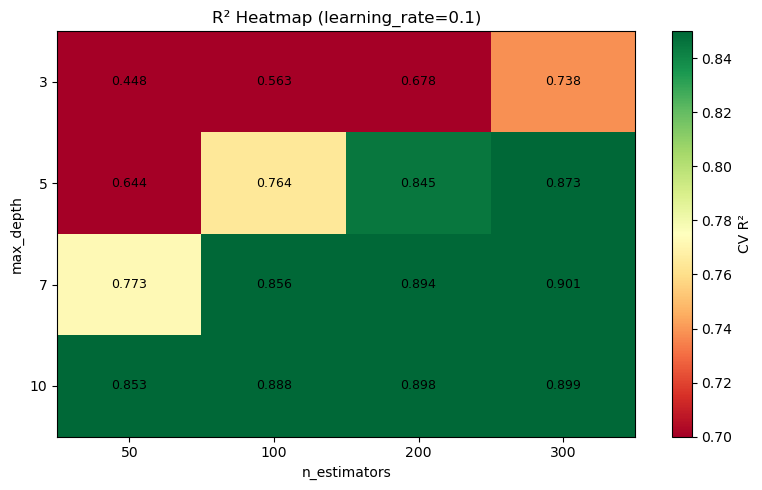

In [4]:
# Heatmap: max_depth vs n_estimators (at best learning_rate)
best_lr = grid.best_params_['learning_rate']
mask = results['param_learning_rate'] == best_lr

pivot = results[mask].pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=0.85)
plt.colorbar(label='CV R²')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.title(f'R² Heatmap (learning_rate={best_lr})')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMRegressor was fitted with feature names")
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

from data_prep import prepare_data, DISEASES, DISEASE_SHORT_NAMES, POLLUTANTS

models = {}
# Toggle hyperparameter tuning (quick search). Set to False to skip tuning.
DO_HYPERPARAM_TUNING = True
RANDOM_SEARCH_ITERS = 12
for disease in DISEASES:
    data = prepare_data(target_disease=disease, lag_years=0, feature_names=POLLUTANTS)
    X_train = data.X_train
    X_test = data.X_test
    monotone_constraints = [1] * len(POLLUTANTS)
    # Conservative defaults to reduce overfitting; optionally run a small randomized search
    base_params = dict(
        n_estimators=300,
        learning_rate=0.1,
        random_state=20,
        monotone_constraints=monotone_constraints,
        verbose=-1,
        verbosity=-1,
    )
    base_model = LGBMRegressor(**base_params)

    if DO_HYPERPARAM_TUNING:
        param_distributions = {
            'num_leaves': [4, 6, 8, 12],
            'max_depth': [3, 5, 7],
            'min_data_in_leaf': [20, 50, 100],
            'min_gain_to_split': [0.0, 0.01, 0.1, 1.0],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'reg_alpha': [0.0, 0.1, 1.0],
            'reg_lambda': [0.0, 0.1, 1.0],
            'learning_rate': [0.05, 0.1]
        }
        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_distributions,
            n_iter=RANDOM_SEARCH_ITERS,
            scoring='neg_mean_squared_error',
            cv=3,
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        search.fit(X_train, data.y_train)
        model = search.best_estimator_
        # Print best hyperparameters chosen by CV (concise)
        short_name = DISEASE_SHORT_NAMES[disease]
        print(f"Best params for {short_name}: {search.best_params_}")
    else:
        model = base_model
        model.fit(X_train, data.y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(data.y_test, y_pred)
    rmse = mean_squared_error(data.y_test, y_pred)
    models[disease] = {'model': model, 'r2': r2, 'rmse': rmse, 'data': data}
    short_name = DISEASE_SHORT_NAMES[disease]
    print(f"{short_name:25s} | R² = {r2:.4f} | RMSE = {rmse:.1f}")

# FEATURE IMPORTANCES

print("\n" + "="*50)
print("TOP 5 POLLUTANTS PER DISEASE")
print("="*50)
for disease, m in models.items():
    raw = np.array(m['model'].feature_importances_, dtype=float)
    if raw.sum() > 0:
        norm = raw / raw.sum() * 100.0
    else:
        norm = np.zeros_like(raw)
    importances = dict(zip(POLLUTANTS, norm))
    top = sorted(importances.items(), key=lambda x: -x[1])[:5]
    short_name = DISEASE_SHORT_NAMES[disease]
    top_str = ", ".join([f"{p} ({v:.0f}%)" for p, v in top])
    print(f"{short_name:25s} | {top_str}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best params for Lung Cancer: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 12, 'min_gain_to_split': 0.0, 'min_data_in_leaf': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Lung Cancer               | R² = 0.3140 | RMSE = 35459367.3
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params for Pneumoconiosis: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 12, 'min_gain_to_split': 0.0, 'min_data_in_leaf': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Pneumoconiosis            | R² = 0.1676 | RMSE = 19511.4
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params for Pneumoconiosis: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 12, 'min_gain_to_split': 0.0, 'min_data_in_leaf': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Pneumoconiosis            | R² = 0.1676 | RMSE = 19511.4
Fitting 3 folds for each of 12 candidates, totalli

Latest Model
```
PYTORCH MLP - ALL DISEASES
==================================================
Lung Cancer               | R² = 0.8718
Pneumoconiosis            | R² = 0.9558
COPD                      | R² = 0.6374
````
